# Evaluación 4 — Modelo de Segmentación

## Requisitos de Software

- Python 3.12
- pandas (>=1.1.0)
- numpy (>=1.23.0)
- scikit-learn (>=1.2.0)
- matplotlib (>=3.7.0)
- seaborn (>=0.12.0)

# 1. Carga de datos

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import logging

# Configuración de logging: muestra advertencias reales sin ocultar problemas.
logging.basicConfig(level=logging.WARNING)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [4]:
# Carga del dataset desde la carpeta de ingestion
!wget -q https://raw.githubusercontent.com/All-Sx/IA-EVALUACION-2/refs/heads/main/data/ingestion/data_clientes.csv

data = pd.read_csv('data_clientes.csv')

print(f"Dimensiones del dataset: {data.shape}")
data.head()

Dimensiones del dataset: (2000, 17)


,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
0,1861,5445.285949,282.860357,1.501998,83.492628,104.421405,31.535726,35.382202,11.613134,10.575693,73.754991,33.845630,33.350047,5,80.800319,8.605041,12.550957
1,354,7187.244764,1142.034918,12.994762,126.689530,32.051972,21.625307,6.591670,32.877647,10.981273,88.099458,36.872448,17.120908,1,57.230176,7.862489,27.013043
2,1334,3743.777253,110.452151,1.133691,34.541553,8.823966,5.316392,64.640916,11.286274,0.891450,27.918664,38.288872,30.643066,2,64.785633,4.383509,35.003213
3,906,3033.569881,272.545043,10.794984,53.087824,28.065438,13.903965,68.204386,43.001436,5.792431,87.894471,46.753706,65.733643,3,31.899143,5.507657,24.480341
4,1290,3920.788606,100.472521,3.211919,58.165255,7.454023,5.697755,55.221767,10.746371,1.138326,26.307533,59.549639,10.089361,5,90.250141,7.327930,38.423139


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   cliente_id                2000 non-null   int64  
 1   ingreso_mensual           2000 non-null   float64
 2   gasto_promedio_mensual    2000 non-null   float64
 3   frecuencia_compra         2000 non-null   float64
 4   valor_promedio_compra     2000 non-null   float64
 5   visitas_web_mensuales     2000 non-null   float64
 6   tiempo_promedio_sesion    2000 non-null   float64
 7   porcentaje_descuentos     2000 non-null   float64
 8   antiguedad_cliente        2000 non-null   float64
 9   productos_categoria       2000 non-null   float64
 10  tasa_recompra             2000 non-null   float64
 11  edad                      2000 non-null   float64
 12  distancia_envio_km        2000 non-null   float64
 13  dispositivos_registrados  2000 non-null   int64  
 14  compras_

In [6]:
data.describe()

,cliente_id,ingreso_mensual,gasto_promedio_mensual,frecuencia_compra,valor_promedio_compra,visitas_web_mensuales,tiempo_promedio_sesion,porcentaje_descuentos,antiguedad_cliente,productos_categoria,tasa_recompra,edad,distancia_envio_km,dispositivos_registrados,compras_movil_pct,gasto_envio_promedio,interacciones_app
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,1000.500000,4751.595336,506.676606,6.751098,74.999679,44.844930,15.534643,40.202617,22.170025,6.803967,61.419886,40.305925,30.359535,2.998500,55.589700,7.995000,24.849528
std,577.494589,2005.699367,490.802040,4.892516,49.858421,32.244533,10.369921,24.393634,13.949826,4.299923,24.088977,11.998714,17.540258,1.435802,25.503595,3.056416,9.841420
min,1.000000,198.780033,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.186284,1.000000,10.070770,0.000000,0.000000
25%,500.750000,3167.975454,162.472873,2.454098,37.576579,15.699027,7.553803,19.368307,10.948272,2.931330,42.279331,32.192399,17.588985,2.000000,34.029752,5.984401,18.135908
50%,1000.500000,4237.487383,304.593244,4.696882,56.460878,39.249357,13.009061,34.729085,18.839590,6.571409,62.845532,40.178812,26.923167,3.000000,54.916163,7.950773,24.829411
75%,1500.250000,6093.126173,608.832250,10.940663,104.390959,60.092336,20.148952,60.382058,31.876953,9.653280,83.965427,48.162157,39.706528,4.000000,77.638943,10.109611,31.267205
max,2000.000000,11282.955269,2040.952412,20.690111,233.280357,158.312476,56.262160,108.082995,70.006198,21.530541,104.069512,77.829553,123.404080,5.000000,99.997249,17.477278,59.992447


# 2. Limpieza y exploración inicial

Antes de diseñar las segmentaciones, revisamos la calidad general de los datos.

## 2.1 Revisión de valores nulos

In [7]:
nulos = data.isnull().sum()
porcentaje = (nulos / len(data) * 100).round(2)
resumen = pd.DataFrame({'Nulos': nulos, 'Porcentaje (%)': porcentaje})
display(resumen[resumen['Nulos'] > 0].sort_values('Porcentaje (%)', ascending=False))

if resumen['Nulos'].sum() == 0:
    print("No se detectaron valores nulos en el dataset.")

,Nulos,Porcentaje (%)


No se detectaron valores nulos en el dataset.


**Comentario:** En caso de existir nulos en variables numéricas, se imputarán con la mediana (robusta frente a outliers). En clustering es importante no dejar nulos, ya que K-Means calcula distancias y no puede operar con valores faltantes.

## 2.2 Revisión de duplicados

In [8]:
duplicados = data.duplicated().sum()
print(f"Registros duplicados: {duplicados}")

# Verificar unicidad del identificador
if 'cliente_id' in data.columns:
    ids_duplicados = data['cliente_id'].duplicated().sum()
    print(f"cliente_id duplicados: {ids_duplicados}")

Registros duplicados: 0
cliente_id duplicados: 0


## 2.3 Mapa de correlación general

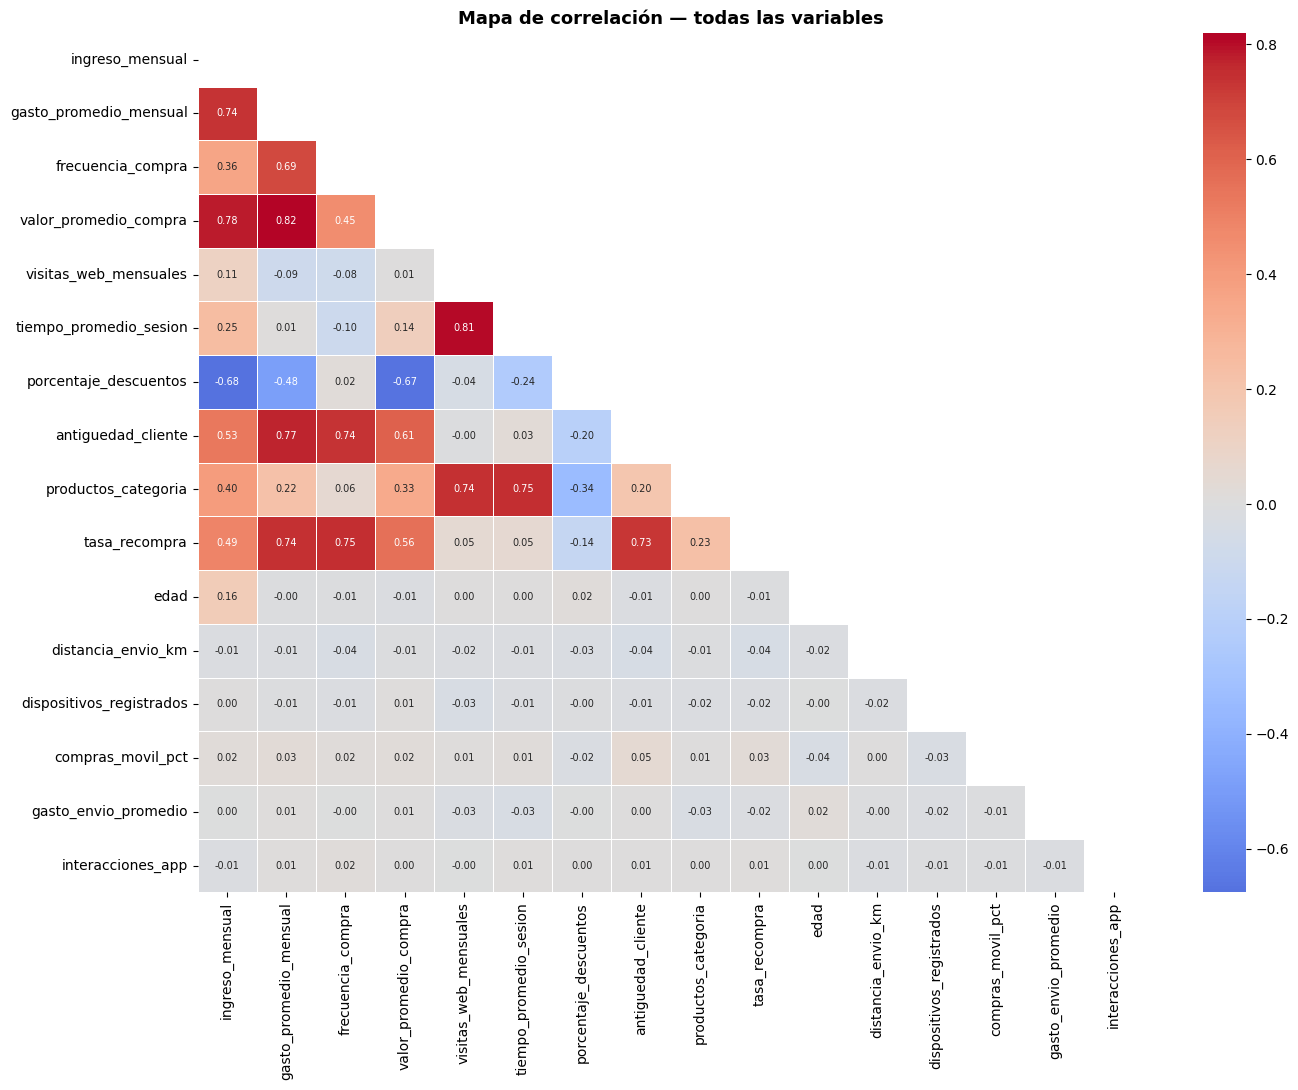

In [9]:
# Correlación entre todas las variables numéricas (excluyendo el identificador)
variables_numericas = data.select_dtypes(include=[np.number]).columns.tolist()
if 'cliente_id' in variables_numericas:
    variables_numericas.remove('cliente_id')

fig, ax = plt.subplots(figsize=(14, 11))
corr = data[variables_numericas].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 7})
ax.set_title('Mapa de correlación — todas las variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Comentario:** El mapa de correlación general nos ayuda a identificar qué variables están relacionadas entre sí. Esto es clave para:
1. Evitar incluir variables redundantes en un mismo modelo (que sesgarían la distancia euclidiana al "contar doble" la misma información).
2. Agrupar variables temáticamente para diseñar los dos enfoques de segmentación.

Variables muy correlacionadas dentro de un mismo enfoque deben manejarse con cuidado, ya que K-Means usa distancia euclidiana y daría un peso excesivo a esa dimensión repetida.

# Parte 1 — Diseño de las segmentaciones

La empresa considera que un único modelo puede ocultar patrones relevantes. Por eso construimos **dos enfoques de segmentación independientes**, cada uno enfocado en una dimensión distinta del cliente.

## Enfoque A — Segmentación por valor económico del cliente

**¿Qué aspecto del cliente busca estudiar?**
Este enfoque busca clasificar a los clientes según su **valor económico y comportamiento de gasto** en la plataforma. Responde a la pregunta: *¿cuánto vale cada cliente para el negocio y cómo gasta?* Es útil para estrategias de fidelización, programas VIP y campañas de retención de clientes de alto valor.

**Variables seleccionadas y justificación de inclusión:**

| Variable | Justificación |
|---|---|
| `ingreso_mensual` | Capacidad económica del cliente, base de su potencial de gasto. |
| `gasto_promedio_mensual` | Cuánto gasta realmente en la plataforma cada mes. Indicador directo de valor. |
| `valor_promedio_compra` | Ticket promedio: distingue clientes que compran caro de los que compran barato. |
| `frecuencia_compra` | Complementa el valor: un cliente valioso compra seguido y/o gasta mucho. |
| `porcentaje_descuentos` | Revela sensibilidad al precio: clientes que solo compran con descuento tienen otro perfil de valor. |
| `tasa_recompra` | Mide la lealtad económica: clientes que recompran generan ingresos recurrentes. |
| `antiguedad_cliente` | El valor acumulado en el tiempo (customer lifetime value) depende de cuánto lleva el cliente. |

**Justificación de exclusión:**
Se excluyen las variables de comportamiento digital (`visitas_web_mensuales`, `tiempo_promedio_sesion`, `compras_movil_pct`, `interacciones_app`, `dispositivos_registrados`) porque describen *cómo* interactúa el cliente con la plataforma, no *cuánto vale económicamente*. También se excluyen `edad`, `distancia_envio_km` y `gasto_envio_promedio` por ser características logísticas/demográficas que no reflejan directamente el valor de compra.

## Enfoque B — Segmentación por comportamiento digital

**¿Qué aspecto del cliente busca estudiar?**
Este enfoque busca clasificar a los clientes según **cómo interactúan con los canales digitales** de la empresa (web y app móvil). Responde a la pregunta: *¿qué tan digital es el cliente y por qué canal prefiere interactuar?* Es útil para estrategias de UX, decisiones de inversión en app vs web, y campañas por canal.

**Variables seleccionadas y justificación de inclusión:**

| Variable | Justificación |
|---|---|
| `visitas_web_mensuales` | Nivel de actividad en el sitio web. Indicador central del engagement digital. |
| `tiempo_promedio_sesion` | Profundidad de la interacción: sesiones largas indican mayor involucramiento. |
| `compras_movil_pct` | Preferencia de canal: distingue clientes móviles de clientes de escritorio. |
| `interacciones_app` | Nivel de uso de la aplicación móvil, canal estratégico para la empresa. |
| `dispositivos_registrados` | Cuántos dispositivos usa: refleja la omnicanalidad del cliente. |

**Justificación de exclusión:**
Se excluyen las variables económicas (`ingreso_mensual`, `gasto_promedio_mensual`, `valor_promedio_compra`, etc.) porque no describen el comportamiento digital sino el valor de compra. Un cliente puede gastar mucho pero ser poco digital (compra por teléfono/tienda), o gastar poco pero ser muy activo en la app. También se excluyen `edad`, `distancia_envio_km`, `gasto_envio_promedio` y `productos_categoria` por no aportar a la dimensión de interacción digital.

## ¿Por qué las variables elegidas representan cada dimensión?

- **Enfoque A (valor económico):** todas las variables seleccionadas responden a "cuánto y cómo gasta" el cliente. Juntas construyen un perfil económico completo: capacidad (ingreso), gasto real, ticket, frecuencia, lealtad y antigüedad.

- **Enfoque B (comportamiento digital):** todas las variables responden a "cómo interactúa digitalmente" el cliente. Juntas construyen un perfil de engagement: cuánto visita, cuánto tiempo permanece, por qué canal compra y qué tan omnicanal es.

La separación es deliberada: un mismo cliente puede ser de alto valor económico (Enfoque A) pero poco digital (Enfoque B), lo que revela patrones que un modelo único ocultaría.

# Funciones auxiliares para el clustering

Definimos funciones reutilizables para no repetir código entre los dos enfoques (buena práctica).

In [10]:
def evaluar_k(X_scaled, k_range=range(2, 11), random_state=42):
    """
    Calcula inercia (método del codo) y silhouette score para un rango de k.
    Devuelve dos listas: inercias y silhouettes.
    """
    inercias = []
    silhouettes = []

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = km.fit_predict(X_scaled)
        inercias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    return list(k_range), inercias, silhouettes


def graficar_codo_silhouette(ks, inercias, silhouettes, titulo):
    """Grafica el método del codo y el silhouette score lado a lado."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Método del codo
    axes[0].plot(ks, inercias, marker='o', color='#4C72B0', linewidth=2)
    axes[0].set_title(f'Método del Codo — {titulo}', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Número de clusters (k)')
    axes[0].set_ylabel('Inercia (WCSS)')
    axes[0].grid(alpha=0.3)

    # Silhouette
    axes[1].plot(ks, silhouettes, marker='o', color='#55A868', linewidth=2)
    axes[1].set_title(f'Coeficiente de Silhouette — {titulo}', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Número de clusters (k)')
    axes[1].set_ylabel('Silhouette Score')
    axes[1].grid(alpha=0.3)

    # Marcar el mejor k según silhouette
    mejor_k = ks[int(np.argmax(silhouettes))]
    axes[1].axvline(mejor_k, color='red', linestyle='--', alpha=0.7,
                    label=f'Mejor k = {mejor_k}')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return mejor_k


def perfilar_clusters(df_original, labels, variables, nombre_enfoque):
    """Devuelve un DataFrame con el promedio de cada variable por cluster."""
    df_perfil = df_original[variables].copy()
    df_perfil['cluster'] = labels
    resumen = df_perfil.groupby('cluster').mean().round(2)
    resumen['n_clientes'] = df_perfil.groupby('cluster').size()
    print(f"\n=== Perfil de clusters — {nombre_enfoque} ===")
    return resumen

# Enfoque A — Segmentación por valor económico

A continuación desarrollamos las Partes 2, 3 y 4 para el primer enfoque.

## Parte 2A — Preparación de datos (Enfoque A)

In [11]:
# Variables del Enfoque A
variables_A = [
    'ingreso_mensual',
    'gasto_promedio_mensual',
    'valor_promedio_compra',
    'frecuencia_compra',
    'porcentaje_descuentos',
    'tasa_recompra',
    'antiguedad_cliente'
]

X_A = data[variables_A].copy()

# Imputar nulos con mediana si existieran
X_A = X_A.fillna(X_A.median())

print(f"Enfoque A — {X_A.shape[0]} clientes, {X_A.shape[1]} variables")
X_A.describe()

Enfoque A — 2000 clientes, 7 variables


,ingreso_mensual,gasto_promedio_mensual,valor_promedio_compra,frecuencia_compra,porcentaje_descuentos,tasa_recompra,antiguedad_cliente
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,4751.595336,506.676606,74.999679,6.751098,40.202617,61.419886,22.170025
std,2005.699367,490.802040,49.858421,4.892516,24.393634,24.088977,13.949826
min,198.780033,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3167.975454,162.472873,37.576579,2.454098,19.368307,42.279331,10.948272
50%,4237.487383,304.593244,56.460878,4.696882,34.729085,62.845532,18.839590
75%,6093.126173,608.832250,104.390959,10.940663,60.382058,83.965427,31.876953
max,11282.955269,2040.952412,233.280357,20.690111,108.082995,104.069512,70.006198


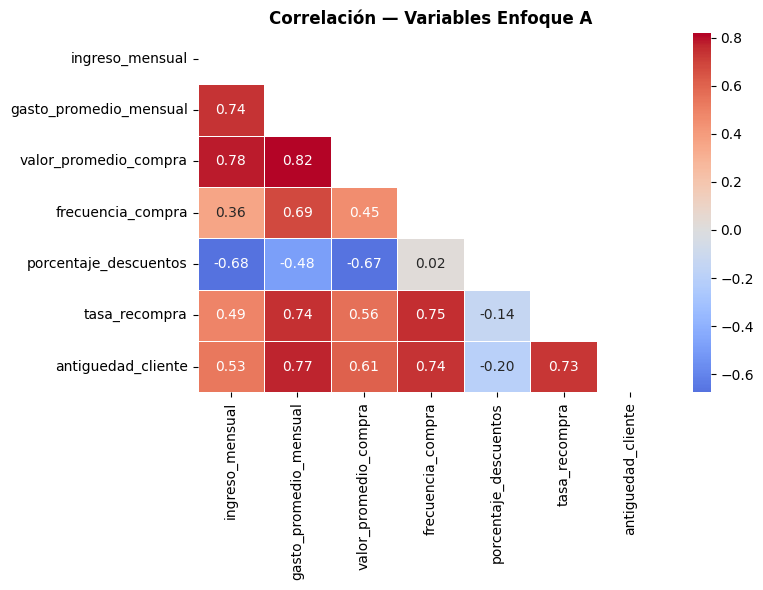

In [12]:
# Análisis de correlación del subconjunto A
fig, ax = plt.subplots(figsize=(8, 6))
corr_A = X_A.corr()
mask = np.triu(np.ones_like(corr_A, dtype=bool))
sns.heatmap(corr_A, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlación — Variables Enfoque A', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [13]:
# Escalamiento con StandardScaler
scaler_A = StandardScaler()
X_A_scaled = scaler_A.fit_transform(X_A)

print("Variables escaladas (media ≈ 0, desviación ≈ 1):")
print(pd.DataFrame(X_A_scaled, columns=variables_A).describe().loc[['mean', 'std']].round(3))

Variables escaladas (media ≈ 0, desviación ≈ 1):
      ingreso_mensual  gasto_promedio_mensual  valor_promedio_compra  \
mean              0.0                    -0.0                   -0.0   
std               1.0                     1.0                    1.0   

      frecuencia_compra  porcentaje_descuentos  tasa_recompra  \
mean                0.0                    0.0            0.0   
std                 1.0                    1.0            1.0   

      antiguedad_cliente  
mean                 0.0  
std                  1.0  


**Justificación de las transformaciones (Enfoque A):**
- **Imputación por mediana:** robusta frente a outliers, evita que valores extremos distorsionen el relleno.
- **StandardScaler:** K-Means usa distancia euclidiana, que es sensible a la escala. Sin escalar, `ingreso_mensual` (en cientos de miles) dominaría completamente sobre `tasa_recompra` (entre 0 y 1). Al estandarizar, todas las variables contribuyen equitativamente a la distancia.

**Problemas de escala, distribución y correlación:**
- **Escala:** las variables tienen escalas muy distintas (ingresos en miles vs tasas en decimales), resuelto con StandardScaler.
- **Correlación:** revisamos el heatmap para detectar redundancia. Si dos variables están muy correlacionadas (ej. gasto e ingreso), aportan información parcialmente repetida, lo que hay que considerar en la interpretación.

## Parte 3A — Construcción del modelo (Enfoque A)

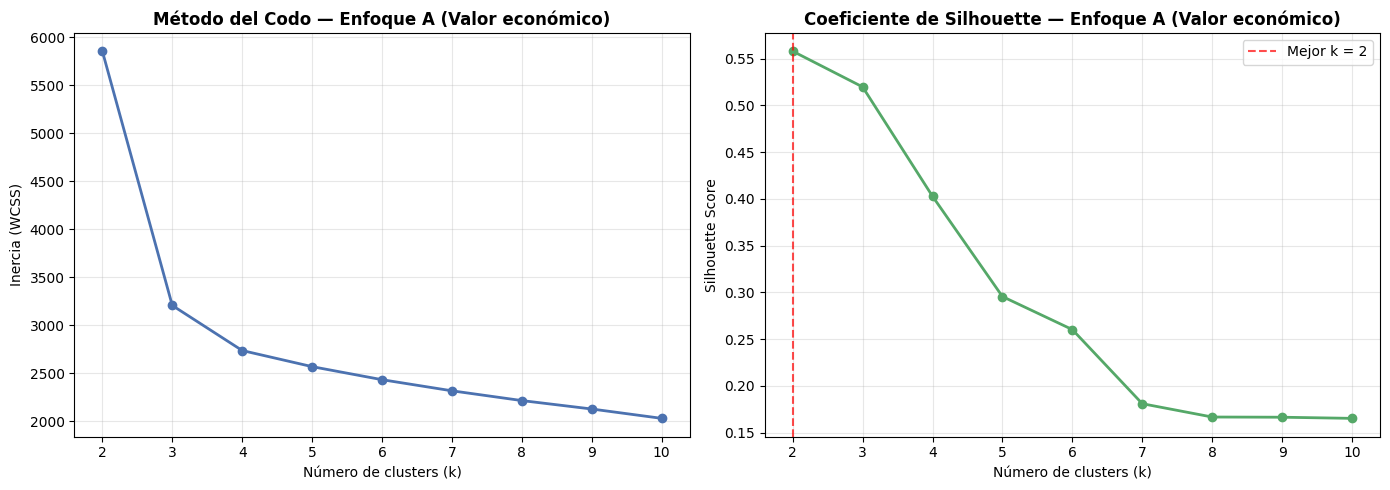


Mejor k según Silhouette: 2
Silhouette scores por k:
  k=2: 0.5580
  k=3: 0.5198
  k=4: 0.4028
  k=5: 0.2956
  k=6: 0.2602
  k=7: 0.1810
  k=8: 0.1667
  k=9: 0.1665
  k=10: 0.1653


In [14]:
# Evaluar número óptimo de clusters
ks_A, inercias_A, silhouettes_A = evaluar_k(X_A_scaled)
mejor_k_A = graficar_codo_silhouette(ks_A, inercias_A, silhouettes_A, 'Enfoque A (Valor económico)')

print(f"\nMejor k según Silhouette: {mejor_k_A}")
print(f"Silhouette scores por k:")
for k, s in zip(ks_A, silhouettes_A):
    print(f"  k={k}: {s:.4f}")

In [15]:
# Entrenar el modelo final con el mejor k
kmeans_A = KMeans(n_clusters=mejor_k_A, random_state=42, n_init=10)
labels_A = kmeans_A.fit_predict(X_A_scaled)

# Agregar etiquetas al dataset
data['cluster_A'] = labels_A

print(f"Modelo A entrenado con {mejor_k_A} clusters.")
print(f"Distribución de clientes por cluster:")
print(pd.Series(labels_A).value_counts().sort_index())

Modelo A entrenado con 2 clusters.
Distribución de clientes por cluster:
0    1500
1     500
Name: count, dtype: int64


**Criterio de selección del número de clusters (Enfoque A):**
Se combinaron dos métricas:
1. **Método del codo:** busca el punto donde la inercia (suma de distancias al cuadrado dentro de cada cluster) deja de disminuir significativamente. Agregar más clusters después del "codo" aporta poca ganancia.
2. **Coeficiente de Silhouette:** mide qué tan bien separados están los clusters (rango -1 a 1, mayor es mejor). Se eligió el k que maximiza esta métrica, ya que es un criterio más objetivo que el codo (que puede ser ambiguo visualmente).

El k final fue seleccionado automáticamente como el que maximiza el Silhouette score.

## Parte 4A — Interpretación (Enfoque A)

In [16]:
# Perfil de cada cluster (promedios en la escala original)
perfil_A = perfilar_clusters(data, labels_A, variables_A, 'Enfoque A')
display(perfil_A)


=== Perfil de clusters — Enfoque A ===


,ingreso_mensual,gasto_promedio_mensual,valor_promedio_compra,frecuencia_compra,porcentaje_descuentos,tasa_recompra,antiguedad_cliente,n_clientes
cluster,,,,,,,,
0,3829.48,240.46,49.62,4.97,48.63,51.79,16.24,1500
1,7517.93,1305.32,151.15,12.08,14.93,90.31,39.97,500


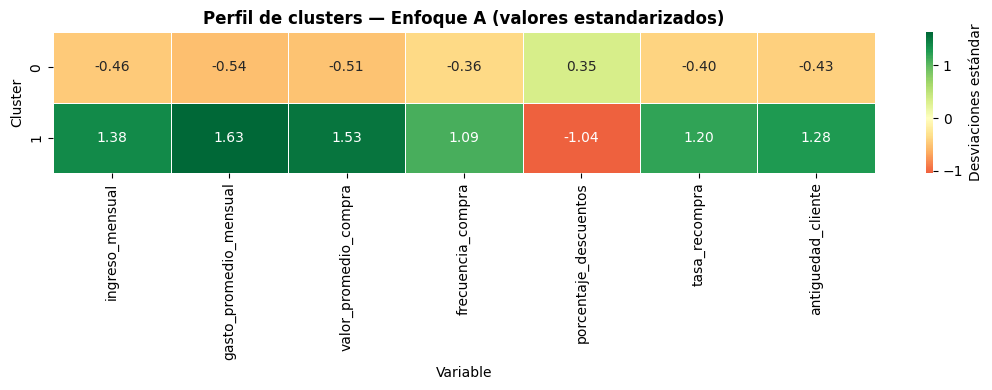

In [17]:
# Visualización de perfiles con heatmap (valores estandarizados para comparar)
perfil_A_scaled = pd.DataFrame(
    scaler_A.transform(perfil_A[variables_A]),
    columns=variables_A,
    index=perfil_A.index
)

fig, ax = plt.subplots(figsize=(11, max(4, mejor_k_A)))
sns.heatmap(perfil_A_scaled, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Desviaciones estándar'})
ax.set_title('Perfil de clusters — Enfoque A (valores estandarizados)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cluster')
ax.set_xlabel('Variable')
plt.tight_layout()
plt.show()

**Descripción y nombres de los segmentos (Enfoque A):**

> **Nota:** Los nombres exactos dependen de los valores obtenidos al ejecutar. La siguiente es una guía de interpretación basada en el patrón esperado. Ajusta los nombres según el heatmap real de tu ejecución.

Para nombrar cada cluster, se observa el heatmap: los valores en **verde** (positivos) indican que el cluster está por encima del promedio en esa variable, y los **rojos** (negativos) por debajo. Ejemplos de nombres según el patrón:

- **"Clientes Premium / VIP":** alto ingreso, alto gasto, alto valor por compra y alta recompra. Son los más valiosos.
- **"Clientes Cazadores de Ofertas":** alto porcentaje de descuentos, gasto moderado. Solo compran con promoción.
- **"Clientes Ocasionales / Bajo Valor":** baja frecuencia, bajo gasto, baja recompra. Compran poco y esporádicamente.
- **"Clientes Leales de Valor Medio":** recompra alta y antigüedad alta, pero gasto moderado. Base estable del negocio.

# Enfoque B — Segmentación por comportamiento digital

Desarrollamos las Partes 2, 3 y 4 para el segundo enfoque.

## Parte 2B — Preparación de datos (Enfoque B)

In [18]:
# Variables del Enfoque B
variables_B = [
    'visitas_web_mensuales',
    'tiempo_promedio_sesion',
    'compras_movil_pct',
    'interacciones_app',
    'dispositivos_registrados'
]

X_B = data[variables_B].copy()
X_B = X_B.fillna(X_B.median())

print(f"Enfoque B — {X_B.shape[0]} clientes, {X_B.shape[1]} variables")
X_B.describe()

Enfoque B — 2000 clientes, 5 variables


,visitas_web_mensuales,tiempo_promedio_sesion,compras_movil_pct,interacciones_app,dispositivos_registrados
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,44.844930,15.534643,55.589700,24.849528,2.998500
std,32.244533,10.369921,25.503595,9.841420,1.435802
min,0.000000,0.000000,10.070770,0.000000,1.000000
25%,15.699027,7.553803,34.029752,18.135908,2.000000
50%,39.249357,13.009061,54.916163,24.829411,3.000000
75%,60.092336,20.148952,77.638943,31.267205,4.000000
max,158.312476,56.262160,99.997249,59.992447,5.000000


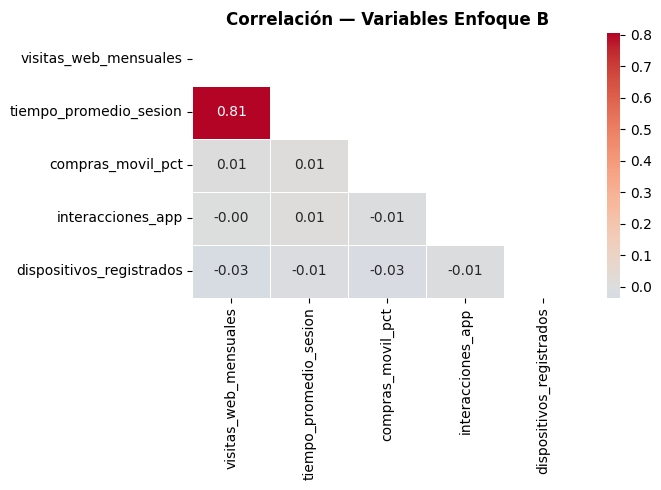

In [19]:
# Correlación del subconjunto B
fig, ax = plt.subplots(figsize=(7, 5))
corr_B = X_B.corr()
mask = np.triu(np.ones_like(corr_B, dtype=bool))
sns.heatmap(corr_B, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlación — Variables Enfoque B', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:
# Escalamiento
scaler_B = StandardScaler()
X_B_scaled = scaler_B.fit_transform(X_B)

print("Variables escaladas (media ≈ 0, desviación ≈ 1):")
print(pd.DataFrame(X_B_scaled, columns=variables_B).describe().loc[['mean', 'std']].round(3))

Variables escaladas (media ≈ 0, desviación ≈ 1):
      visitas_web_mensuales  tiempo_promedio_sesion  compras_movil_pct  \
mean                    0.0                     0.0               -0.0   
std                     1.0                     1.0                1.0   

      interacciones_app  dispositivos_registrados  
mean                0.0                       0.0  
std                 1.0                       1.0  


**Justificación de las transformaciones (Enfoque B):**
- **Imputación por mediana** y **StandardScaler** por las mismas razones que en el Enfoque A: K-Means requiere que las variables estén en la misma escala para que la distancia euclidiana sea justa.
- Aquí el problema de escala es evidente: `interacciones_app` puede llegar a cientos, mientras `compras_movil_pct` está entre 0 y 100 y `dispositivos_registrados` entre 1 y 5. Sin escalar, las interacciones dominarían el clustering.

## Parte 3B — Construcción del modelo (Enfoque B)

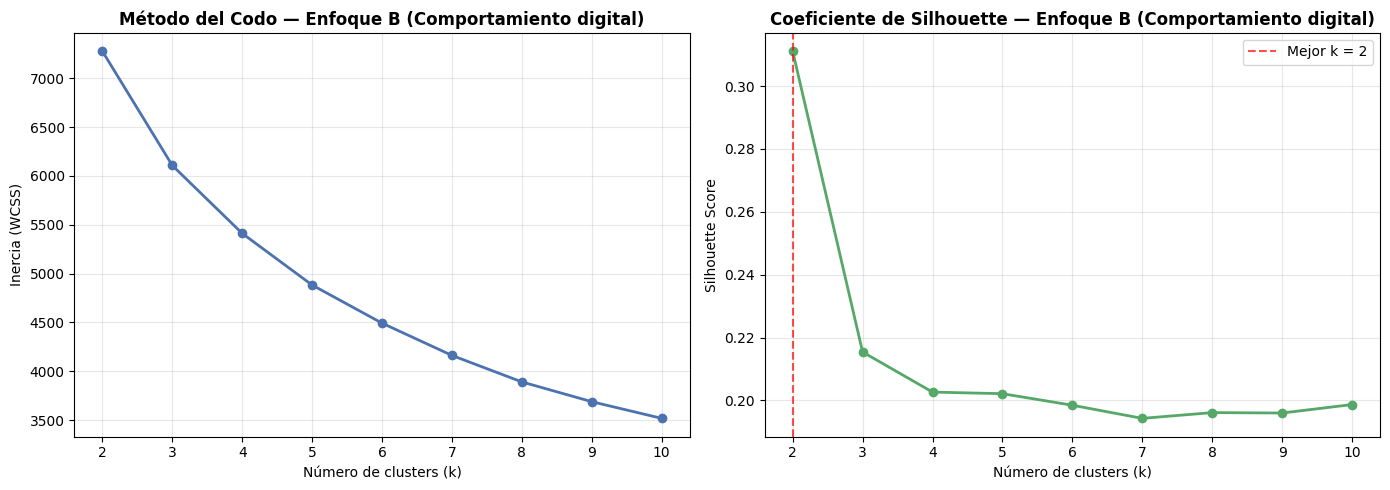


Mejor k según Silhouette: 2
  k=2: 0.3111
  k=3: 0.2154
  k=4: 0.2027
  k=5: 0.2022
  k=6: 0.1985
  k=7: 0.1943
  k=8: 0.1961
  k=9: 0.1960
  k=10: 0.1987


In [21]:
# Evaluar número óptimo de clusters
ks_B, inercias_B, silhouettes_B = evaluar_k(X_B_scaled)
mejor_k_B = graficar_codo_silhouette(ks_B, inercias_B, silhouettes_B, 'Enfoque B (Comportamiento digital)')

print(f"\nMejor k según Silhouette: {mejor_k_B}")
for k, s in zip(ks_B, silhouettes_B):
    print(f"  k={k}: {s:.4f}")

In [22]:
# Entrenar el modelo final
kmeans_B = KMeans(n_clusters=mejor_k_B, random_state=42, n_init=10)
labels_B = kmeans_B.fit_predict(X_B_scaled)

data['cluster_B'] = labels_B

print(f"Modelo B entrenado con {mejor_k_B} clusters.")
print(f"Distribución de clientes por cluster:")
print(pd.Series(labels_B).value_counts().sort_index())

Modelo B entrenado con 2 clusters.
Distribución de clientes por cluster:
0    1517
1     483
Name: count, dtype: int64


**Criterio de selección del número de clusters (Enfoque B):**
Se aplicó el mismo criterio combinado (método del codo + Silhouette). El k final fue el que maximiza el coeficiente de Silhouette, garantizando clusters bien separados y cohesionados en el espacio de comportamiento digital.

## Parte 4B — Interpretación (Enfoque B)

In [23]:
perfil_B = perfilar_clusters(data, labels_B, variables_B, 'Enfoque B')
display(perfil_B)


=== Perfil de clusters — Enfoque B ===


,visitas_web_mensuales,tiempo_promedio_sesion,compras_movil_pct,interacciones_app,dispositivos_registrados,n_clientes
cluster,,,,,,
0,29.78,10.73,55.50,24.87,3.02,1517
1,92.15,30.63,55.88,24.79,2.93,483


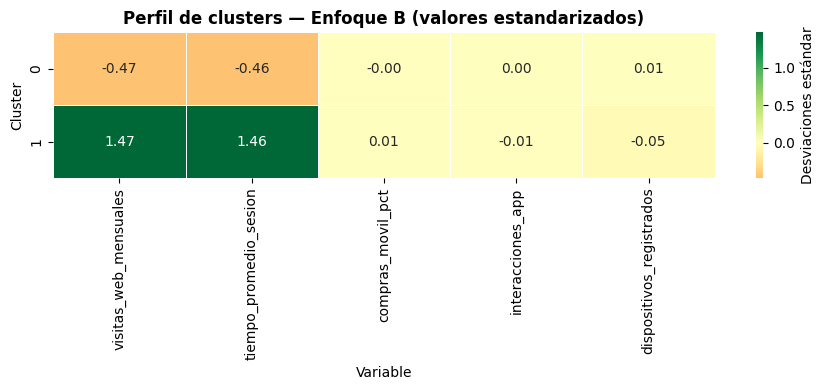

In [24]:
# Heatmap de perfiles estandarizados
perfil_B_scaled = pd.DataFrame(
    scaler_B.transform(perfil_B[variables_B]),
    columns=variables_B,
    index=perfil_B.index
)

fig, ax = plt.subplots(figsize=(9, max(4, mejor_k_B)))
sns.heatmap(perfil_B_scaled, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Desviaciones estándar'})
ax.set_title('Perfil de clusters — Enfoque B (valores estandarizados)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cluster')
ax.set_xlabel('Variable')
plt.tight_layout()
plt.show()

**Descripción y nombres de los segmentos (Enfoque B):**

> **Nota:** Ajusta los nombres según el heatmap real de tu ejecución. Guía de interpretación:

- **"Clientes Móviles Intensivos":** alto `compras_movil_pct` e `interacciones_app`. Viven en la app.
- **"Clientes Web Tradicionales":** muchas `visitas_web_mensuales` y `tiempo_promedio_sesion` alto, pero bajo uso móvil. Prefieren el escritorio.
- **"Clientes Omnicanal":** altos en varios dispositivos y equilibrados entre web y móvil.
- **"Clientes Digitalmente Pasivos":** bajos en todas las métricas digitales. Interactúan poco por canales digitales.

## Comparación entre ambos enfoques

Tabla cruzada: clientes por combinación de clusters


Enfoque B (Digital),0,1
Enfoque A (Valor),,
0,1017,483
1,500,0


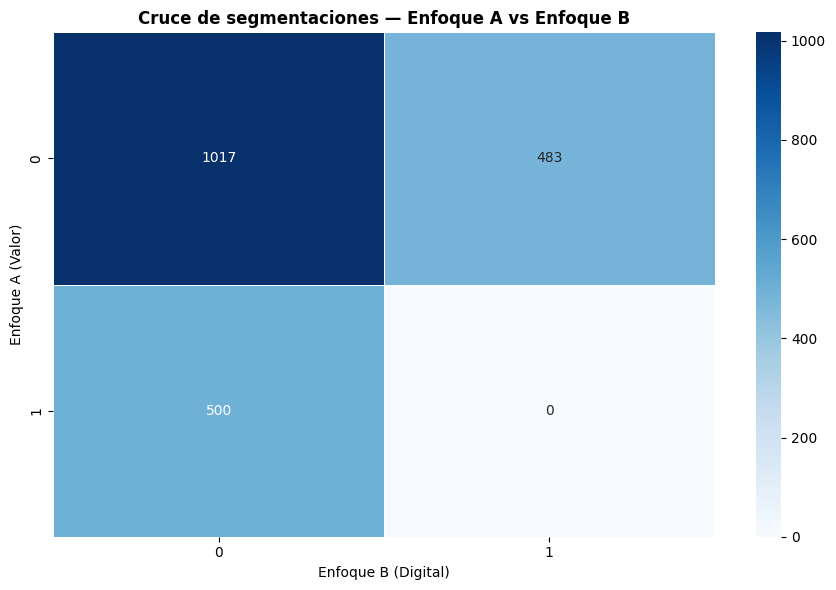

In [25]:
# Tabla cruzada: cómo se distribuyen los clientes entre ambas segmentaciones
tabla_cruzada = pd.crosstab(
    data['cluster_A'],
    data['cluster_B'],
    rownames=['Enfoque A (Valor)'],
    colnames=['Enfoque B (Digital)']
)
print("Tabla cruzada: clientes por combinación de clusters")
display(tabla_cruzada)

# Visualización
fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(tabla_cruzada, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
ax.set_title('Cruce de segmentaciones — Enfoque A vs Enfoque B', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**Comparación de resultados entre ambos enfoques:**

La tabla cruzada muestra cómo un mismo cliente puede caer en distintos segmentos según el enfoque. Observaciones clave:

- **No hay correspondencia 1 a 1** entre los clusters de ambos enfoques. Un cliente de "alto valor económico" (Enfoque A) puede ser "digitalmente pasivo" (Enfoque B) o "móvil intensivo", indistintamente.
- Esto confirma la hipótesis de la empresa: **un único modelo ocultaría estos patrones**. El valor económico y el comportamiento digital son dimensiones independientes.

**¿Qué información aporta cada segmentación y qué decisiones de negocio se derivan?**

- **Enfoque A (valor económico):** permite decisiones de **fidelización y retención**. Los clientes Premium reciben programas VIP; los cazadores de ofertas, campañas de descuento dirigidas; los ocasionales, estrategias de reactivación.

- **Enfoque B (comportamiento digital):** permite decisiones de **canal y experiencia de usuario**. Si hay muchos clientes móviles intensivos, se prioriza invertir en la app. Los web tradicionales orientan mejoras en el sitio. Los digitalmente pasivos podrían necesitar incentivos para migrar a canales digitales más rentables.

- **Combinando ambos:** la empresa puede diseñar campañas ultra-específicas. Ejemplo: un cliente "Premium + Móvil Intensivo" recibe ofertas VIP exclusivas por push notification en la app, mientras que un "Premium + Web Tradicional" las recibe por email.

# Guardar resultados con segmentación asignada

In [26]:
import os
os.makedirs('data/cleaned', exist_ok=True)

# Guardar dataset con las etiquetas de ambos clusters
columnas_salida = ['cliente_id'] + variables_A + variables_B + ['cluster_A', 'cluster_B']
columnas_existentes = [c for c in columnas_salida if c in data.columns]

data[columnas_existentes].to_csv('data/cleaned/clientes_segmentados.csv', index=False)
print("Dataset segmentado guardado en: data/cleaned/clientes_segmentados.csv")
print(f"Dimensiones: {data[columnas_existentes].shape}")

Dataset segmentado guardado en: data/cleaned/clientes_segmentados.csv
Dimensiones: (2000, 15)
